In [152]:
import cga_utils
import prompt_versions
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [153]:
from langchain.globals import set_llm_cache
from langchain_community.cache import SQLiteCache

set_llm_cache(SQLiteCache(database_path=".langchain.ollama38.db"))

In [154]:
from langchain_community.chat_models import ChatOllama
llm = ChatOllama(model="qwen3:4b", temperature = 0.0, top_p = 1, repeat_penalty=1, presence_penalty=0, frequency_penalty=0)  # vagy bármely más elérhető Ollama modell

In [155]:
import pandas as pd
messages = prompt_versions.prompt_versions['V22']
messages = [(a, t.replace('/no_think','')) for (a,t)  in messages]
messages[-1] = ( messages[-1][0],  messages[-1][1] + "/no_think" ) 



#problematic_qids = list(pd.read_csv('res/e37.csv').query('error_code == "selection_error" and calc_pattern == "(#+#)/#"')['qid'])
#df = pd.read_csv('res/e38_19.csv')
#problematic_qids = list(df[df["question"].str.contains("percentage change")]['qid'])

#res = cga_utils.execute_datset_predictions(llm, messages, problematic_qids)
res = cga_utils.execute_datset_predictions(llm, messages)

0it [00:00, ?it/s]

b2786c1a-37de-4120-b03c-32bf5c81f157
What was the change in the amount for Appliances in 2019 from 2018? Success: -94.0
<< 680-774 || [680.0, 774.0, -94.0] || [680.0, 774.0] || True >>
fe11f001-3bfe-4089-8108-412676f0a780
What was the percentage change in the amount for Appliances in 2019 from 2018? Success: -12.14
<< (680-774)/774 || [680.0, 774.0, -12.144702842377262] || [680.0, 774.0, 774.0] || True >>
5103aed0-b4e8-4fae-bf78-e2c9f4ba84cf
What is the difference between the domestic and international discount rates as at September 30, 2019? Success: 2.1
<< 4.00 - 1.90  || [4.0, 1.9] || [4.0, 1.9] || True >>
4dc8be43-d8d9-4b08-9ffd-9c19012361ce
What is the year on year percentage change in domestic discount rate between 2018 and 2019? Success: 6.67
<< (4.00 - 3.75)/3.75  || [3.75, 4.0, 6.666666666666667] || [4.0, 3.75, 3.75] || True >>
6c44a1a8-0785-43a0-90ab-7e21df2c57d9
What is the year on year percentage change in international expected return on plan assets between 2018 and 2019? 

In [156]:
annotated_results = cga_utils.annotate_results(res)
#annotated_results.to_csv('res/Ollama_2_gemma3n_e4b_code_values_v11_m1.csv')
cga_utils.calc_overall_value_match(annotated_results)

0.7243460764587525

In [160]:
annotated_results['aggr_calc_pattern'].value_counts()

aggr_calc_pattern
#-#                    134
(#-#)/#                100
(#+#)/#                 89
#/#                     49
(#+#+#)/#               26
#+#                     21
other                   20
#/#-#                    9
-#-#                     8
#%-#%                    7
-(#+#)/#                 5
(#%+#%)/#                5
#+#+#                    4
[(#+#)/#]-[(#+#)/#]      4
-(#+#+#)/#               3
-#-(-#)                  3
(#%+#%+#%)/#             2
#*#                      2
#-(-#)                   2
(-#-(-#))/-#             2
(-#-#)/#                 2
Name: count, dtype: int64

In [128]:
set(annotated_results['aggr_calc_pattern'])

{'#%-#%',
 '#*#',
 '#+#',
 '#+#+#',
 '#-#',
 '#-(-#)',
 '#/#',
 '#/#-#',
 '(#%+#%)/#',
 '(#%+#%+#%)/#',
 '(#+#)/#',
 '(#+#+#)/#',
 '(#-#)/#',
 '(-#-#)/#',
 '(-#-(-#))/-#',
 '-#-#',
 '-#-(-#)',
 '-(#+#)/#',
 '-(#+#+#)/#',
 '[(#+#)/#]-[(#+#)/#]',
 'other'}

In [129]:

cga_utils.calc_overall_em(annotated_results), cga_utils.calc_overall_em_alt(annotated_results)

(0.6659959758551308, 0.6659959758551308)

In [130]:
annotated_results.to_csv('res/e38_22.csv')

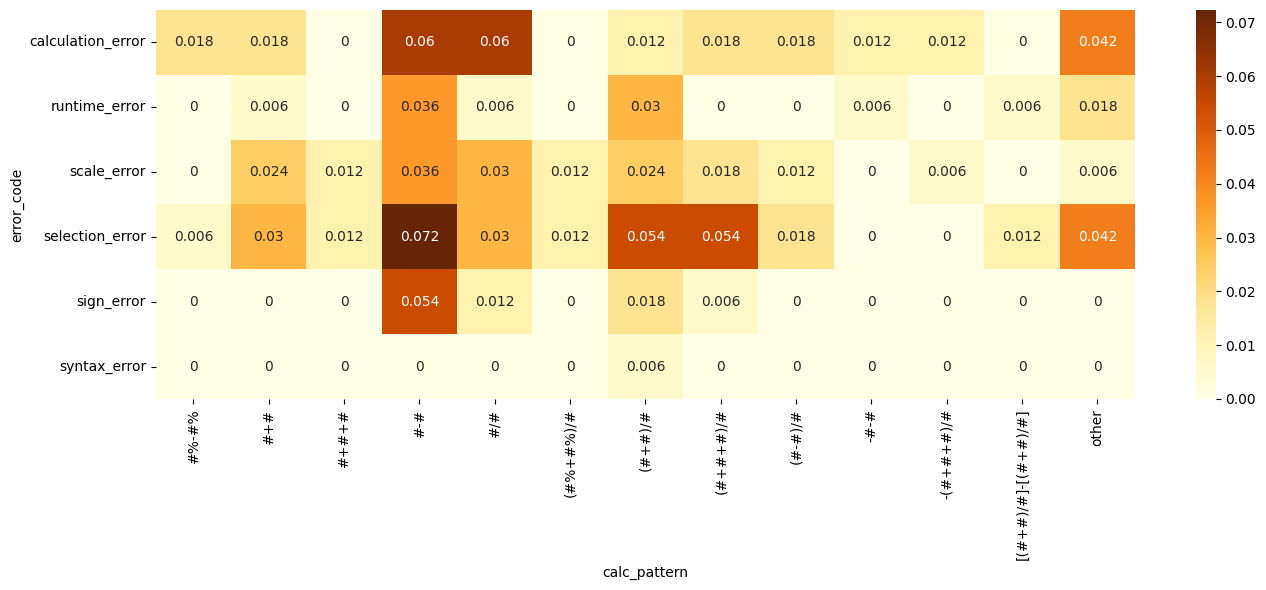

166

In [151]:
df = annotated_results.query('error_code != "none"')
cga_utils.crosstab_heatmap(df, 'error_code', 'calc_pattern', None, 0, 2)
len(df)


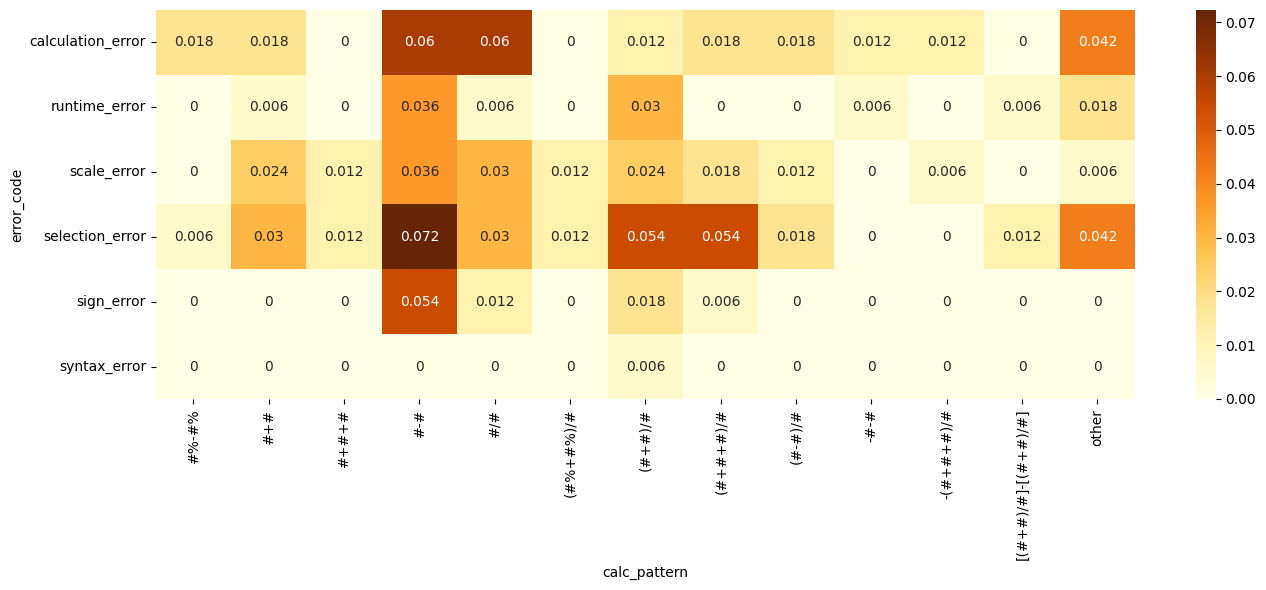

In [148]:
cga_utils.crosstab_heatmap(df, 'error_code', 'calc_pattern', None, 0, 2)

/home/apandy/Tabular/tab_small/cga_utils.py:342: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy


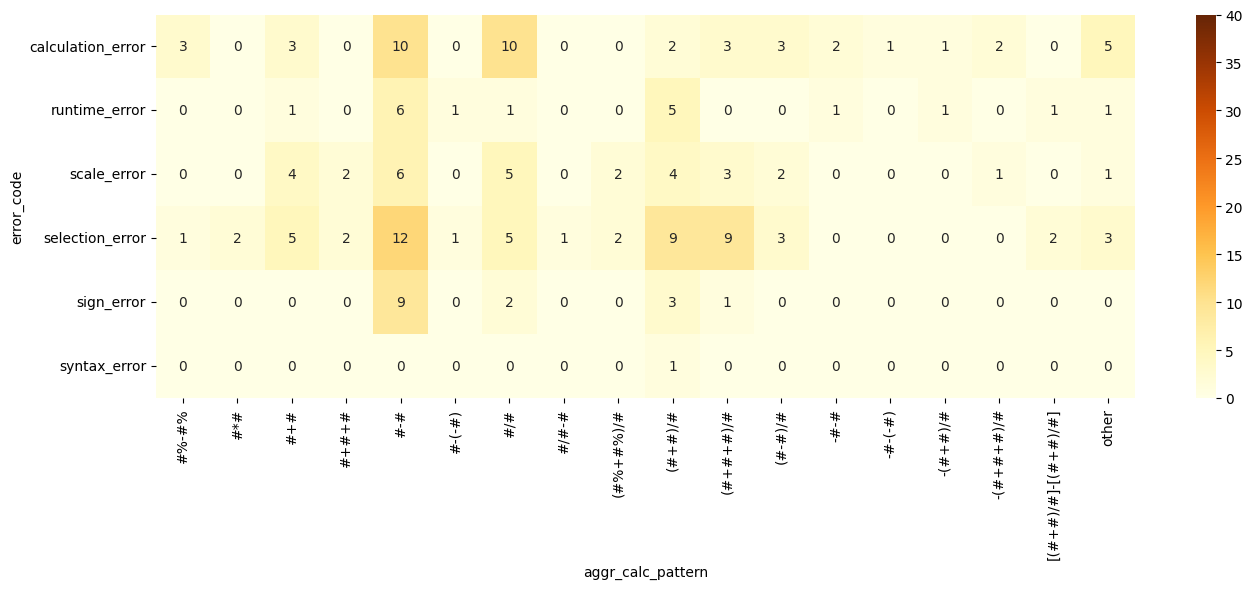

166

In [140]:
df = annotated_results.query('error_code != "none"')
cga_utils.crosstab_heatmap(df, 'error_code', 'aggr_calc_pattern', 40)
len(df)

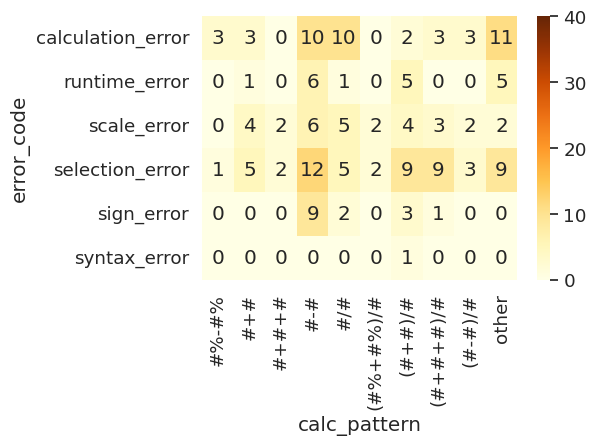

166

In [168]:
df = annotated_results.query('error_code != "none"')
cga_utils.crosstab_heatmap(df, 'error_code', 'calc_pattern', 40,0,3) 
len(df)

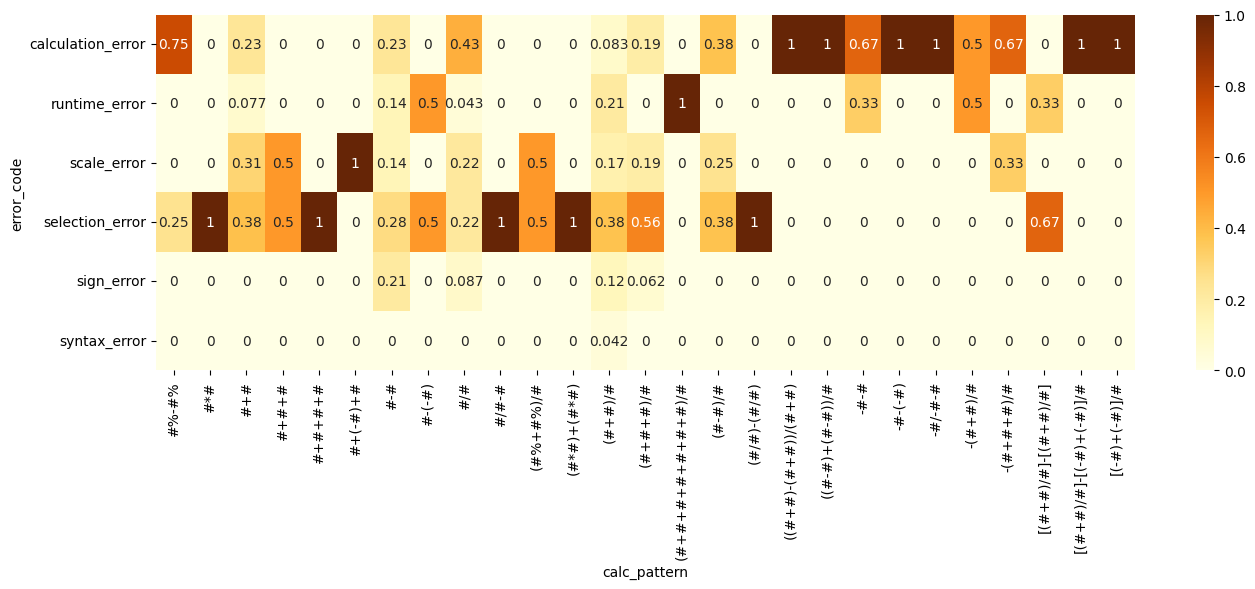

In [34]:
import seaborn as sns
import matplotlib.pyplot as plt
def crosstab_heatmap(df, x, y, vmax=None):
    # 1. Kontingenciatábla
    pattern_error_matrix = pd.crosstab(df[x], df[y], normalize='columns')
    
    # 3. Hőtérkép
    plt.figure(figsize=(14, 6))
    sns.heatmap(pattern_error_matrix, cmap='YlOrBr', vmax=vmax, annot=True )
    
    #plt.title("Hibatípusok előfordulása számítási minták szerint (normalizálva)")
    plt.xlabel(y)
    plt.ylabel(x)
    plt.xticks(rotation=90)
    plt.tight_layout()
    plt.show()
crosstab_heatmap(df, 'error_code', 'calc_pattern')

In [65]:
import re
from collections import Counter

def aggregate_calc_patterns(patterns, replacement="#", other_group_szie=4):

    def merge(text):        
        while (f'{replacement}+{replacement}+{replacement}' in text):
            text = text.replace(f'{replacement}+{replacement}+{replacement}', f'{replacement}+{replacement}')
        return text
    def aggr(text, counts):
        if counts[text] > other_group_szie:
            return text
        else:
            return "other"
    merged = [merge(text) for text in texts]
    counts = Counter(merged)
    aggregated = [aggr(text, counts) for text in texts]
    return aggregated

In [68]:
patterns = cga_utils.replace_numbers(annotated_results['derivation'])
patterns2 = aggregate_calc_patterns(patterns)
set(patterns2)

{'#%-#%',
 '#+#',
 '#-#',
 '#/#',
 '#/#-#',
 '(#%+#%)/#',
 '(#+#)/#',
 '(#-#)/#',
 '-#-#',
 '-(#+#)/#',
 'other'}

Series([], Name: exact_match, dtype: float64)


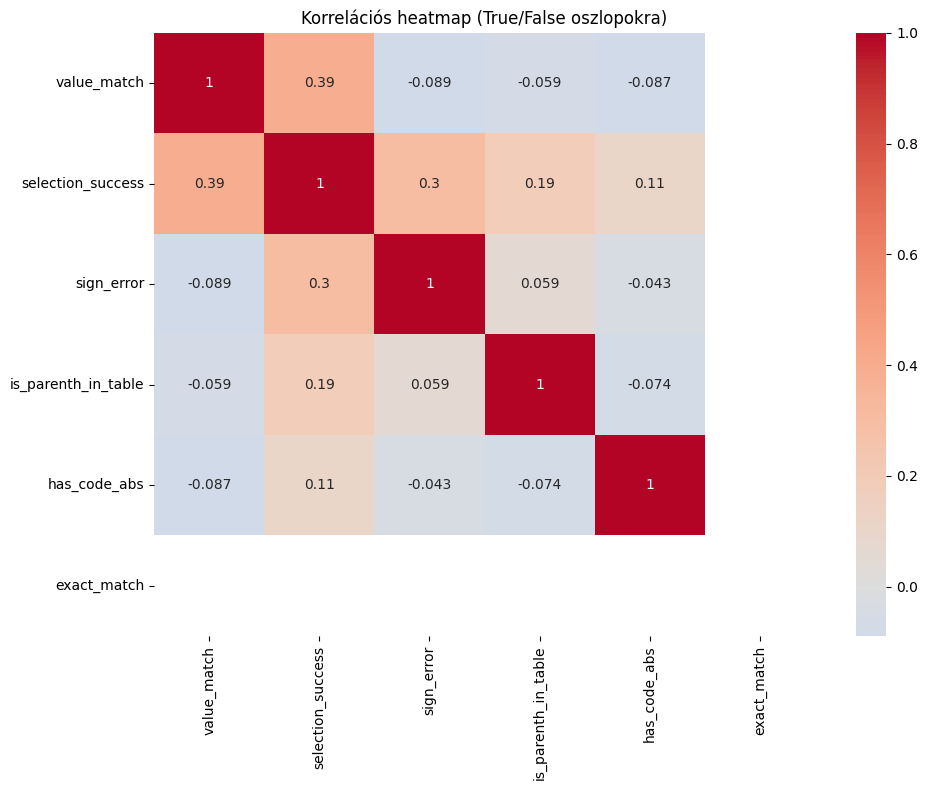

In [44]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

df = annotated_results.query('error_code != "none"')

# 1. Csak a True/False típusú oszlopokat szűrjük ki
bool_cols = df.select_dtypes(include=['bool'])

# 2. Korrelációs mátrix számítása
corr = bool_cols.corr()
em_corr = bool_cols.corr()['exact_match'].dropna().sort_values(ascending=False)

print(em_corr)

# 3. Heatmap megjelenítés
plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, cmap="coolwarm", center=0)

plt.title("Korrelációs heatmap (True/False oszlopokra)")
plt.tight_layout()
plt.show()


In [42]:
bool_cols

,value_match,selection_success,sign_error,is_parenth_in_table,has_code_abs,exact_match
6,False,False,False,False,False,False
8,False,False,False,True,False,False
16,False,False,False,True,False,False
17,False,True,False,True,False,False
22,False,False,False,True,False,False
...,...,...,...,...,...,...
482,False,False,False,True,False,False
484,True,True,False,False,False,False
489,False,True,False,True,False,False
490,False,True,True,True,False,False
